In [ ]:
import os
import random
import time
import json
from pathlib import Path
from typing import Dict, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
from torchvision import transforms, datasets, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50, DenseNet121, ResNet101
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, f1_score
import numpy as np

import json
import datetime

from google.colab import files
import zipfile
import os

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [ ]:
items = os.listdir(path)
for item in items:
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"\n📁 Folder: {item}")
        subitems = os.listdir(item_path)
        print(f"   Contains: {subitems[:5]}..." if len(subitems) > 5 else f"   Contains: {subitems}")


📁 Folder: seg_train
   Contains: ['seg_train']

📁 Folder: seg_pred
   Contains: ['seg_pred']

📁 Folder: seg_test
   Contains: ['seg_test']


In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = os.path.join(path, "seg_train/seg_train")   # sesuai struktur dataset Kaggle
test_dir  = os.path.join(path, "seg_test/seg_test")


In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# train_datagen = ImageDataGenerator(rescale=1/255., validation_split=0.2)

# train_gen = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="training"
# )

# val_gen = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     subset="validation"
# )

# test_datagen = ImageDataGenerator(rescale=1/255.)
# test_gen = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode="categorical",
#     shuffle=False
# )

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-60]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True)
]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 258s 649ms/step - accuracy: 0.5348 - loss: 1.1482 - val_accuracy: 0.5011 - val_loss: 1.5272
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 176s 501ms/step - accuracy: 0.6505 - loss: 0.8716 - val_accuracy: 0.4822 - val_loss: 1.5331
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 506ms/step - accuracy: 0.6918 - loss: 0.8047 - val_accuracy: 0.3584 - val_loss: 2.6294
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 508ms/step - accuracy: 0.7095 - loss: 0.7451 - val_accuracy: 0.5164 - val_loss: 1.3512
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 507ms/step - accuracy: 0.7157 - loss: 0.7332 - val_accuracy: 0.4151 - val_loss: 2.1031
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 178s 508ms/step - accuracy: 0.7287 - loss: 0.7033 - val_accuracy: 0.6594 - val_loss: 0.8081
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 175s 498ms/step - accuracy: 0.7481 - loss: 0.6691 - val_accuracy: 0.3167 - val_loss: 2.5370
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 177s 504ms/step - accuracy: 0.7554 -

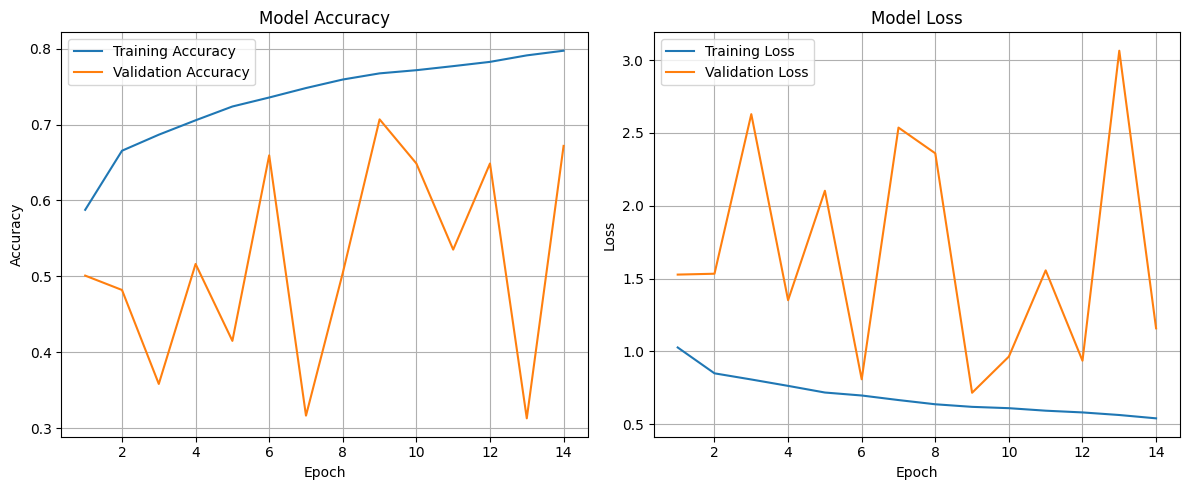

In [ ]:
# --- Ambil nilai dari history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


----------
ResNet Moodified

In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    validation_split=0.1,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet101(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True)
]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 266s 605ms/step - accuracy: 0.8214 - loss: 0.4801 - val_accuracy: 0.9023 - val_loss: 0.2751
Epoch 2/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 215s 544ms/step - accuracy: 0.9255 - loss: 0.2081 - val_accuracy: 0.9073 - val_loss: 0.2675
Epoch 3/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 217s 549ms/step - accuracy: 0.9461 - loss: 0.1437 - val_accuracy: 0.9208 - val_loss: 0.2527
Epoch 4/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 218s 551ms/step - accuracy: 0.9589 - loss: 0.1176 - val_accuracy: 0.9165 - val_loss: 0.2507
Epoch 5/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 256s 537ms/step - accuracy: 0.9650 - loss: 0.0956 - val_accuracy: 0.9208 - val_loss: 0.2732
Epoch 6/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 210s 530ms/step - accuracy: 0.9721 - loss: 0.0811 - val_accuracy: 0.9165 - val_loss: 0.3034
Epoch 7/10
395/395 ━━━━━━━━━━━━━━━━━━━━ 208s 528ms/step - accuracy: 0.9744 - loss: 0.0710 - val_accuracy: 0.9180 - val_loss: 0.3351
Epoch 8/10
368/395 ━━━━━━━━━━━━━━━━━━━━ 12s 478ms/step - accuracy: 0.9770 - 

----------------------------


## DENSENET

In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input

In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = os.path.join(path, "seg_train/seg_train")   # sesuai struktur dataset Kaggle
test_dir  = os.path.join(path, "seg_test/seg_test")


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-20]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)   # tambahan dropout untuk cegah overfitting

# x = GlobalAveragePooling2D()(base_model.output)
# x = Dense(256, activation="relu")(x)
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-4), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
from tensorflow.keras.callbacks import ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# callbacks = [
#     EarlyStopping(patience=5, restore_best_weights=True),
#     ModelCheckpoint("best_resnet.keras", save_best_only=True)
# ]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
  9/351 ━━━━━━━━━━━━━━━━━━━━ 39:58 7s/step - accuracy: 0.2399 - loss: 1.8796

KeyboardInterrupt: 

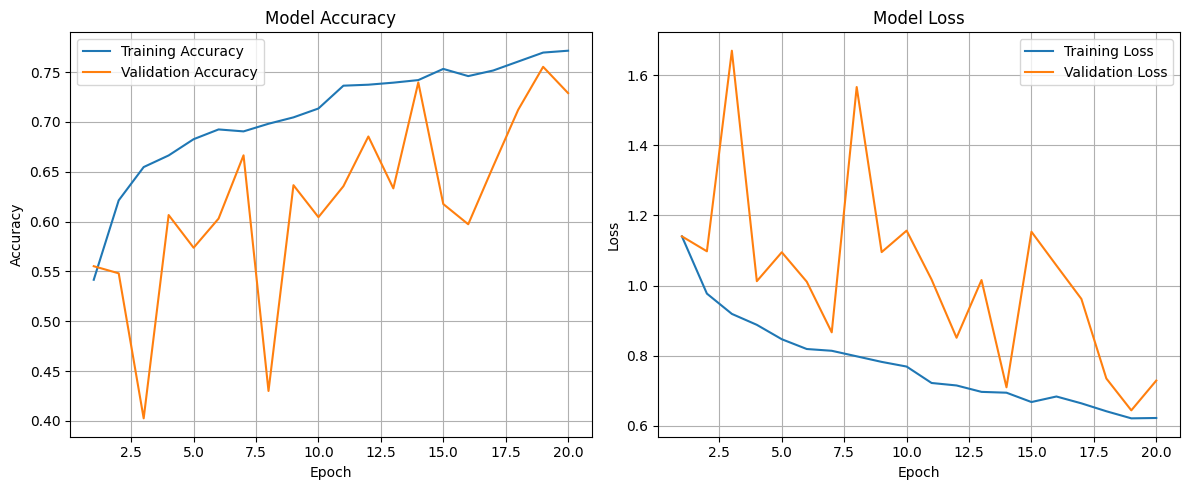

In [ ]:
# --- Ambil nilai dari history ---
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# --- Plot Accuracy ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# --- Plot Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


------------------------


In [ ]:
# Set random seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# --- Konfigurasi ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
train_dir = "traing_data"   # sesuai nama folder kamu
test_dir = "test_data"


In [ ]:
# --- Data Generator dengan split validasi ---

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# --- Build ResNet ---
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224,224,3))
base_model.trainable = True   # fine-tuning

# Freeze layer awal, hanya latih layer terakhir
for layer in base_model.layers[:-40]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)   # tambahan dropout untuk cegah overfitting
output = Dense(6, activation="softmax")(x)

model_resnet = Model(inputs=base_model.input, outputs=output)
model_resnet.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])

# --- Callbacks ---
from tensorflow.keras.callbacks import ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True),
    ModelCheckpoint("best_resnet.keras", save_best_only=True),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

# callbacks = [
#     EarlyStopping(patience=5, restore_best_weights=True),
#     ModelCheckpoint("best_resnet.keras", save_best_only=True)
# ]

# --- Training ---
history = model_resnet.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)

# --- Evaluasi ---
test_loss, test_acc = model_resnet.evaluate(test_gen)
y_pred = model_resnet.predict(test_gen)
y_true = test_gen.classes
y_pred_classes = np.argmax(y_pred, axis=1)

print("ResNet Test Accuracy:", test_acc)
print("ResNet Test F1 Score (macro):", f1_score(y_true, y_pred_classes, average="macro"))
print(classification_report(y_true, y_pred_classes, target_names=list(test_gen.class_indices.keys())))

NameError: name 'ResNet50' is not defined